---
## 1. Imports y configuración

In [42]:
import warnings, os, re, sys
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from scipy.spatial.distance import cosine
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from pymongo import MongoClient, UpdateOne

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
PALETTE = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2',
           '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

print('✓ Imports OK')

✓ Imports OK


In [43]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✓ Dispositivo: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
else:
    print('  Corriendo en CPU — procesar en batches pequeños para evitar OOM')

✓ Dispositivo: cpu
  Corriendo en CPU — procesar en batches pequeños para evitar OOM


---
## 2. Carga del corpus desde MongoDB


In [44]:
client    = MongoClient('mongodb://localhost:27017/')
db        = client['musica']
coleccion = db['canciones']

docs = list(coleccion.find(
    {'Lyrics': {'$exists': True, '$ne': ''}},
    {'_id': 1, 'Song': 1, 'Artist': 1, 'Genre': 1, 'Lyrics': 1}
))
df = pd.DataFrame(docs).dropna(subset=['Genre', 'Lyrics']).copy()
df = df[df['Lyrics'].str.strip().str.len() > 50].reset_index(drop=True)

# Géneros detectados dinámicamente
conteo  = df['Genre'].value_counts()
GENEROS = conteo[conteo >= 20].index.tolist()
df      = df[df['Genre'].isin(GENEROS)].reset_index(drop=True)

print(f'{len(df):,} canciones | {len(GENEROS)} géneros con >=20 canciones')
print()
print(df['Genre'].value_counts().to_string())

9,230 canciones | 10 géneros con >=20 canciones

Genre
Rock          1410
Pop           1307
Hip-Hop       1159
Country       1010
Metal         1008
Jazz           844
Electronic     806
R&B            681
Indie          510
Folk           495


---
## 3. Load BERT from HuggingFace

In [45]:
import subprocess, sys

# Instalar transformers si no está disponible
try:
    from transformers import BertTokenizer, BertForMaskedLM, BertModel
except ImportError:
    print('Instalando transformers...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'transformers', '-q'], check=True)
    from transformers import BertTokenizer, BertForMaskedLM, BertModel

MODELO_BERT = 'bert-base-uncased'

print(f'Cargando tokenizer: {MODELO_BERT}')
tokenizer = BertTokenizer.from_pretrained(MODELO_BERT)

print(f'Loading BertModel (for embeddings)...')
beto = BertModel.from_pretrained(MODELO_BERT, output_hidden_states=False)
beto = beto.to(DEVICE)
beto.eval()

print(f'Loading BertForMaskedLM (for MLM)...')
beto_mlm = BertForMaskedLM.from_pretrained(MODELO_BERT)
beto_mlm = beto_mlm.to(DEVICE)
beto_mlm.eval()

print(f'\n✓ BERT loaded correctly — vocabulary: {tokenizer.vocab_size:,} tokens')


Cargando tokenizer: bert-base-uncased
Loading BertModel (for embeddings)...
Loading BertForMaskedLM (for MLM)...


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



✓ BERT loaded correctly — vocabulary: 30,522 tokens
  Embedding dimension: 768


---
## 4. Contextual Polysemy


In [46]:
def embedding_token_en_oracion(oracion: str, palabra: str,
                               modelo, tok, device, max_length=128):
    """
    Extrae el embedding promedio de todos los sub-tokens que corresponden
    a `palabra` dentro de `oracion`.
    Devuelve un vector numpy de 768 dim, o None si la palabra no aparece.
    """
    oracion_lower = oracion.lower()
    if palabra.lower() not in oracion_lower:
        return None

    encoded = tok(
        oracion,
        return_tensors='pt',
        truncation=True,
        max_length=max_length,
        padding=False
    )
    input_ids = encoded['input_ids'][0].tolist()
    tokens    = tok.convert_ids_to_tokens(input_ids)

    # Identificar qué sub-tokens pertenecen a la palabra objetivo
    palabra_tokens = tok.tokenize(palabra)
    indices = []
    for i in range(len(tokens) - len(palabra_tokens) + 1):
        if tokens[i:i + len(palabra_tokens)] == palabra_tokens:
            indices.extend(range(i, i + len(palabra_tokens)))

    if not indices:
        return None

    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        salida = modelo(**encoded)

    hidden = salida.last_hidden_state[0]   # (seq_len, 768)
    vec    = hidden[indices].mean(dim=0).cpu().numpy()
    return vec


def similitud_cos(v1, v2):
    """Similitud coseno entre dos vectores numpy."""
    return float(1 - cosine(v1, v2))


print('✓ Funciones de embedding definidas')

✓ Funciones de embedding definidas


In [47]:
PALABRAS_POLISEMICAS = ['fire', 'heart', 'light', 'road', 'dark']

# Seleccionar hasta 3 oraciones por género para cada palabra
N_ORACIONES = 3   # oraciones de muestra por género
MAX_LEN_LYRICS = 500  # caracteres de la letra a considerar

print('=== Contextual Polysemy Analysis with BERT ===\n')
print(f'Words analyzed: {PALABRAS_POLISEMICAS}')
print(f'Sentences per genre: {N_ORACIONES}\n')

resultados_polisemia = {}   # { palabra: { genero: [vectores] } }

for palabra in PALABRAS_POLISEMICAS:
    resultados_polisemia[palabra] = defaultdict(list)
    print(f'─── "{palabra}" ───')

    for genero in GENEROS:
        # Filtrar canciones del género que contienen la palabra
        mask = (df['Genre'] == genero) & (
            df['Lyrics'].str.lower().str.contains(palabra, na=False)
        )
        muestra = df[mask].head(N_ORACIONES)

        for _, row in muestra.iterrows():
            # Tomar primera oración relevante que contenga la palabra
            oraciones = [s.strip() for s in row['Lyrics'][:MAX_LEN_LYRICS].split('\n')
                         if palabra.lower() in s.lower() and len(s.strip()) > 15]
            if not oraciones:
                continue
            oracion = oraciones[0]
            vec = embedding_token_en_oracion(oracion, palabra, beto, tokenizer,
                                             DEVICE)
            if vec is not None:
                resultados_polisemia[palabra][genero].append((oracion, vec))

        n = len(resultados_polisemia[palabra][genero])
        if n > 0:
            print(f'  {genero:<14} — {n} embedding(s) extraído(s)')

    print()

print('✓ Extraction complete')

=== Contextual Polysemy Analysis with BERT ===

Words analyzed: ['fire', 'heart', 'light', 'road', 'dark']
Sentences per genre: 3

─── "fire" ───
  Rock           — 1 embedding(s) extraído(s)
  Pop            — 2 embedding(s) extraído(s)
  Hip-Hop        — 2 embedding(s) extraído(s)
  Country        — 3 embedding(s) extraído(s)
  Metal          — 1 embedding(s) extraído(s)
  Jazz           — 2 embedding(s) extraído(s)
  Electronic     — 2 embedding(s) extraído(s)
  R&B            — 1 embedding(s) extraído(s)
  Indie          — 3 embedding(s) extraído(s)
  Folk           — 1 embedding(s) extraído(s)

─── "heart" ───
  Rock           — 1 embedding(s) extraído(s)
  Hip-Hop        — 1 embedding(s) extraído(s)
  Country        — 2 embedding(s) extraído(s)
  Metal          — 2 embedding(s) extraído(s)
  Jazz           — 2 embedding(s) extraído(s)
  Electronic     — 1 embedding(s) extraído(s)
  R&B            — 1 embedding(s) extraído(s)
  Indie          — 1 embedding(s) extraído(s)

─── "lig

In [48]:
print('=== Cosine similarity between embeddings of the same token in different contexts ===\n')
print('Expected: similarity < 1.0 confirms BERT assigns different vectors per context\n')

for palabra in PALABRAS_POLISEMICAS:
    datos_g = resultados_polisemia[palabra]
    generos_con_datos = [g for g in GENEROS if datos_g.get(g)]
    if len(generos_con_datos) < 2:
        print(f'  "{palabra}" — insufficient genres with data, skipped\n')
        continue

    print(f'─── "{palabra}" ───')
    for i in range(len(generos_con_datos)):
        for j in range(i + 1, len(generos_con_datos)):
            g1, g2 = generos_con_datos[i], generos_con_datos[j]
            v1 = datos_g[g1][0][1]
            v2 = datos_g[g2][0][1]
            sim = similitud_cos(v1, v2)
            print(f'  {g1:<14} ↔ {g2:<14}  similitud = {sim:.4f}')

    # Mostrar oraciones de muestra de los primeros dos géneros
    g_ej = generos_con_datos[:2]
    print('  Example sentences:')
    for g in g_ej:
        oracion, _ = datos_g[g][0]
        print(f'    [{g}] {oracion[:90]}')
    print()

=== Cosine similarity between embeddings of the same token in different contexts ===

Expected: similarity < 1.0 confirms BERT assigns different vectors per context

─── "fire" ───
  Rock           ↔ Pop             similitud = 0.6535
  Rock           ↔ Hip-Hop         similitud = 0.6165
  Rock           ↔ Country         similitud = 0.5760
  Rock           ↔ Metal           similitud = 0.6565
  Rock           ↔ Jazz            similitud = 0.5385
  Rock           ↔ Electronic      similitud = 0.6532
  Rock           ↔ R&B             similitud = 0.6559
  Rock           ↔ Indie           similitud = 0.6066
  Rock           ↔ Folk            similitud = 0.6150
  Pop            ↔ Hip-Hop         similitud = 0.6528
  Pop            ↔ Country         similitud = 0.6099
  Pop            ↔ Metal           similitud = 0.7275
  Pop            ↔ Jazz            similitud = 0.5539
  Pop            ↔ Electronic      similitud = 0.6146
  Pop            ↔ R&B             similitud = 0.7002
  Pop    

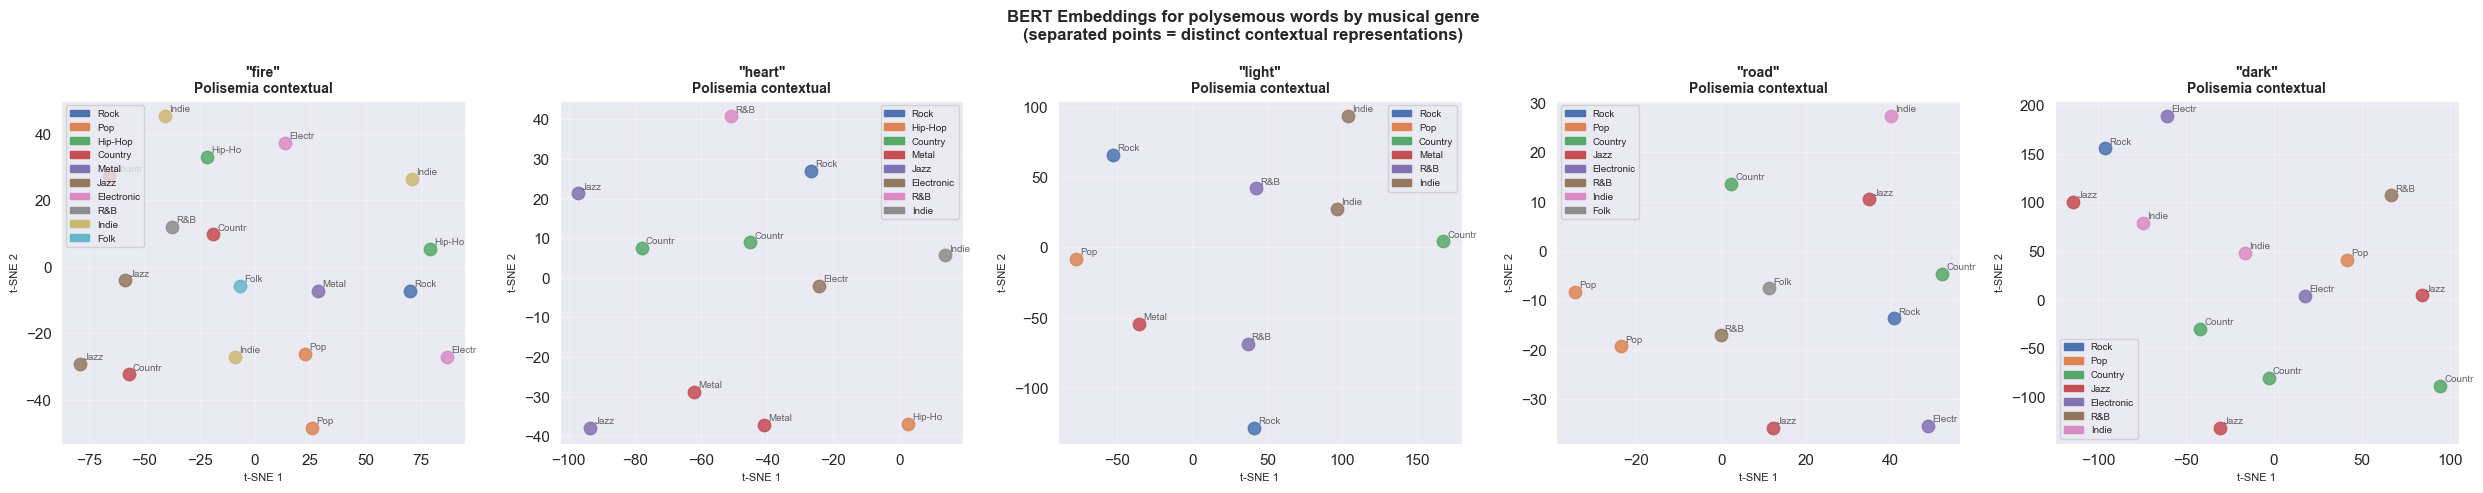

Observation: more dispersion = greater contextual variation captured by BERT.


In [49]:
# Visualización: para cada palabra polisémica, t-SNE de sus embeddings por género
fig, axes = plt.subplots(1, len(PALABRAS_POLISEMICAS),
                         figsize=(5 * len(PALABRAS_POLISEMICAS), 5))

for ax, palabra in zip(axes, PALABRAS_POLISEMICAS):
    vecs, etiquetas = [], []
    for genero in GENEROS:
        for _, vec in resultados_polisemia[palabra].get(genero, []):
            vecs.append(vec)
            etiquetas.append(genero)

    if len(vecs) < 3:
        ax.set_title(f'"{palabra}"\n(insuf. datos)', fontsize=10)
        ax.axis('off')
        continue

    perp = min(5, len(vecs) - 1)
    coords = TSNE(n_components=2, random_state=42,
                  perplexity=perp).fit_transform(np.array(vecs))

    generos_uniq = list(dict.fromkeys(etiquetas))
    color_map    = {g: PALETTE[i % len(PALETTE)] for i, g in enumerate(generos_uniq)}

    for i, (x, y) in enumerate(coords):
        g = etiquetas[i]
        ax.scatter(x, y, color=color_map[g], s=80, alpha=0.85, zorder=3)
        ax.annotate(g[:6], (x, y), fontsize=7, alpha=0.7,
                    xytext=(3, 3), textcoords='offset points')

    ax.set_title(f'"{palabra}"\nPolisemia contextual', fontsize=10, fontweight='bold')
    ax.set_xlabel('t-SNE 1', fontsize=8)
    ax.set_ylabel('t-SNE 2', fontsize=8)

    leyenda = [mpatches.Patch(color=color_map[g], label=g) for g in generos_uniq]
    ax.legend(handles=leyenda, fontsize=7, loc='best')

plt.suptitle(
    'BERT Embeddings for polysemous words by musical genre\n'
    '(separated points = distinct contextual representations)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## 5. Full Song Embeddings


In [50]:
def cls_embedding(texto: str, modelo, tok, device,
                  max_length=512) -> np.ndarray:
    """
    Retorna el vector [CLS] (768 dim) del texto truncado a max_length tokens.
    """
    encoded = tok(
        texto,
        return_tensors='pt',
        truncation=True,
        max_length=max_length,
        padding=False
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        salida = modelo(**encoded)
    return salida.last_hidden_state[0, 0].cpu().numpy()   # token [CLS]


# Procesar en batches para no saturar RAM/GPU
BATCH_SIZE   = 32   # reducir a 8-16 si hay OOM en GPU/CPU
MAX_CANCIONES = None  # None = procesar todas; poner ej. 500 para prueba rápida

df_proc = df.copy() if MAX_CANCIONES is None else df.head(MAX_CANCIONES).copy()

print(f'Generating [CLS] embeddings for {len(df_proc):,} songs...')
print(f'Batch size: {BATCH_SIZE} | Device: {DEVICE}\n')

embeddings_cls = []

for start in range(0, len(df_proc), BATCH_SIZE):
    batch = df_proc.iloc[start: start + BATCH_SIZE]
    for _, row in batch.iterrows():
        texto = row['Lyrics'][:2000]   # primeros 2000 chars antes de tokenizar
        vec   = cls_embedding(texto, beto, tokenizer, DEVICE)
        embeddings_cls.append(vec)

    done = min(start + BATCH_SIZE, len(df_proc))
    print(f'\r  {done}/{len(df_proc)} canciones procesadas', end='', flush=True)

df_proc['emb_beto'] = embeddings_cls
EMB_MATRIX = np.vstack(embeddings_cls)   # (n_canciones, 768)

print(f'\n\n✓ Embedding matrix: {EMB_MATRIX.shape}')


Generating [CLS] embeddings for 9,230 songs...
Batch size: 32 | Device: cpu

  9230/9230 canciones procesadas

✓ Embedding matrix: (9230, 768)
  Dimension per song: 768 (BERT hidden size)


---
## 6. Semantic Search of Songs


In [51]:
def busqueda_semantica(consulta: str, df_emb: pd.DataFrame,
                      matriz: np.ndarray,
                      modelo, tok, device, top_k: int = 5):
    """
    Dado un texto de consulta, devuelve las top_k canciones más similares.
    """
    vec_consulta = cls_embedding(consulta, modelo, tok, device)  # (768,)
    # Similitud coseno con toda la matriz de un golpe
    sims = cosine_similarity(vec_consulta.reshape(1, -1), matriz)[0]
    top_idx = sims.argsort()[::-1][:top_k]
    resultados = []
    for idx in top_idx:
        row = df_emb.iloc[idx]
        resultados.append({
            'rank':     len(resultados) + 1,
            'Song':     row.get('Song', '?'),
            'Artist':   row.get('Artist', '?'),
            'Genre':    row.get('Genre', '?'),
            'similitud': round(float(sims[idx]), 4),
        })
    return resultados


# ── Demo de búsqueda semántica ───────────────────────────────────────────────
CONSULTAS_DEMO = [
    'I miss the love of my life and time does not heal the wound',
    'the party never ends there is music and dancing all night long',
    'I fight for my dreams even when the road is hard',
]

for consulta in CONSULTAS_DEMO:
    print(f'Query: "{consulta}"')
    resultados = busqueda_semantica(consulta, df_proc, EMB_MATRIX,
                                    beto, tokenizer, DEVICE, top_k=5)
    for r in resultados:
        print(f'  {r["rank"]}. [{r["Genre"]:10}] {r["Song"]:30} — {r["Artist"]:20} '
              f'(sim={r["similitud"]:.4f})')
    print()

Query: "I miss the love of my life and time does not heal the wound"
  1. [Rock      ] character-actor                — all-else-failed      (sim=0.9219)
  2. [Metal     ] reflection                     — advent               (sim=0.9143)
  3. [Electronic] the-end                        — funker-vogt          (sim=0.9110)
  4. [Metal     ] Raining Blood                  — Slayer               (sim=0.9050)
  5. [Metal     ] perishing-passion              — disharmonic-orchestra (sim=0.9044)

Query: "the party never ends there is music and dancing all night long"
  1. [Jazz      ] The Long Day Is Over           — Norah Jones          (sim=0.8664)
  2. [Metal     ] raining-murder                 — dark-throne          (sim=0.8640)
  3. [Indie     ] just-so                        — agnes-obel           (sim=0.8618)
  4. [Jazz      ] ev-ry-time-we-say-goodbye      — cole-porter          (sim=0.8608)
  5. [Pop       ] all-these-days-undone          — anything-box         (sim=0.8583)

Query:

---
## 7. Masked Language Model (MLM) by Genre


In [52]:
def predecir_token_enmascarado(oracion_con_mask: str,
                                modelo_mlm, tok, device,
                                top_k: int = 5):
    """
    Recibe una oración con exactamente un [MASK] y devuelve las top_k
    predicciones con su probabilidad.
    """
    if '[MASK]' not in oracion_con_mask:
        raise ValueError('La oración debe contener exactamente un [MASK]')

    encoded  = tok(oracion_con_mask, return_tensors='pt',
                   truncation=True, max_length=128)
    ids      = encoded['input_ids'][0].tolist()
    mask_idx = ids.index(tok.mask_token_id)

    encoded  = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        logits = modelo_mlm(**encoded).logits   # (1, seq_len, vocab)

    probs_mask = torch.softmax(logits[0, mask_idx], dim=-1)
    top_probs, top_ids = probs_mask.topk(top_k)

    return [(tok.decode([tid.item()]).strip(), round(prob.item(), 4))
            for tid, prob in zip(top_ids, top_probs)]


print('✓ MLM function defined')
print()

# Prueba rápida
demo = predecir_token_enmascarado(
    'my [MASK] will never forget the love we shared',
    beto_mlm, tokenizer, DEVICE
)
print('Test: "my [MASK] will never forget the love we shared"')
for tok_pred, prob in demo:
    print(f'  → "{tok_pred}" ({prob:.4f})')

✓ MLM function defined

Test: "my [MASK] will never forget the love we shared"
  → "heart" (0.6867)
  → "soul" (0.0865)
  → "mind" (0.0519)
  → "eyes" (0.0169)
  → "body" (0.0154)


In [53]:

PLANTILLAS_MLM = [
    'my [MASK] will always remember you',
    'in this [MASK] I think of you',
    'the [MASK] never lies when it sings',
    'I will follow my [MASK] even when it hurts',
    'the [MASK] I feel has no name',
]

print('=== Masked Language Model — predictions per template ===\n')

# Para cada plantilla mostramos predicciones globales (todas las canciones)
for plantilla in PLANTILLAS_MLM:
    preds = predecir_token_enmascarado(plantilla, beto_mlm, tokenizer, DEVICE, top_k=8)
    palabras = ', '.join(f'{p} ({s:.3f})' for p, s in preds)
    print(f'Template: "{plantilla}"')
    print(f'  Predictions → {palabras}')
    print()

=== Masked Language Model — predictions per template ===

Template: "my [MASK] will always remember you"
  Predictions → heart (0.183), father (0.063), people (0.061), family (0.054), mother (0.052), son (0.048), children (0.044), soul (0.032)

Template: "in this [MASK] I think of you"
  Predictions → moment (0.357), way (0.195), dream (0.044), light (0.030), room (0.025), instant (0.023), time (0.017), place (0.015)

Template: "the [MASK] never lies when it sings"
  Predictions → world (0.109), heart (0.093), truth (0.067), answer (0.049), sun (0.025), land (0.022), moon (0.017), light (0.013)

Template: "I will follow my [MASK] even when it hurts"
  Predictions → heart (0.356), instincts (0.218), dreams (0.037), gut (0.036), orders (0.030), instinct (0.018), father (0.012), word (0.011)

Template: "the [MASK] I feel has no name"
  Predictions → pain (0.084), way (0.062), peace (0.051), power (0.037), fear (0.036), love (0.033), anger (0.024), emptiness (0.019)



In [54]:
import random
import re
import pandas as pd

random.seed(42)
PATRON_PALABRA = re.compile(r"\b[a-zA-Z']{3,}\b")

def construir_oracion_mascara(lyrics, max_intentos=100):
    if not isinstance(lyrics, str) or len(lyrics.strip()) < 10:
        return None, None

    # 1. Limpieza básica
    texto = re.sub(r'\[.*?\]', '', lyrics)
    texto = texto.replace("\r\n", " ").replace("\r", " ").replace("\n", " ")

    # 2. Como tus letras vienen en un solo bloque, creamos "frases" artificiales
    # Dividimos por palabras y tomamos segmentos de 15 a 20 palabras
    palabras_todas = texto.split()
    if len(palabras_todas) < 10:
        return None, None

    # Intentamos extraer fragmentos aleatorios de la canción
    for _ in range(max_intentos):
        if len(palabras_todas) <= 15:
            indice_inicio = 0
            ventana = palabras_todas
        else:
            indice_inicio = random.randint(0, len(palabras_todas) - 15)
            ventana = palabras_todas[indice_inicio : indice_inicio + 15]

        frase_artificial = " ".join(ventana)

        # 3. Buscar candidatos en este fragmento
        matches = list(PATRON_PALABRA.finditer(frase_artificial))

        if len(matches) >= 3:
            # Seleccionamos una palabra que no sea la primera ni la última para tener contexto
            idx_match = len(matches) // 2
            match_objetivo = matches[idx_match]
            palabra_real = match_objetivo.group()

            inicio, fin = match_objetivo.span()
            oracion_mask = frase_artificial[:inicio] + "[MASK]" + frase_artificial[fin:]

            return oracion_mask, palabra_real

    return None, None

# --- Ejecución ---
print("=== MLM on real corpus sentences (Window Mode) ===")
mlm_por_genero = {}

for genero in GENEROS:
    canciones_g = df_proc[df_proc["Genre"] == genero]
    if canciones_g.empty:
        continue

    oracion_mask, palabra_real = None, None
    # Buscamos en las primeras 50 canciones
    for _, row in canciones_g.head(50).iterrows():
        oracion_mask, palabra_real = construir_oracion_mascara(str(row["Lyrics"]))
        if oracion_mask:
            break

    if not oracion_mask:
        print(f"  {genero:<14} — skipped (still no valid window)")
        continue

    try:
        # Usa el modelo definido en tu notebook (beto_mlm o bert_mlm)
        # IMPORTANTE: Si tu notebook es inglés, asegúrate que el modelo sea bert-base-uncased
        preds = predecir_token_enmascarado(oracion_mask, beto_mlm, tokenizer, DEVICE, top_k=5)
        mlm_por_genero[genero] = {"oracion": oracion_mask, "real": palabra_real, "preds": preds}

        top_preds_str = ", ".join(f"{p}({s:.3f})" for p, s in preds[:3])
        en_top = any(p.lower() == palabra_real.lower() for p, _ in preds)

        print(f"  [{genero}]")
        print(f"    Sentence:  ...{oracion_mask}...")
        print(f"    Real word: \"{palabra_real}\"")
        print(f"    Top-3:     {top_preds_str}")
        print(f"    In top-5?  {'✓ YES' if en_top else '✗ NO'}\n")

    except Exception as e:
        print(f"  {genero:<14} — error: {e}")

=== MLM on real corpus sentences (Window Mode) ===
  [Rock]
    Sentence:  ...I never did say Ill be good [MASK] Thursday comes Its such a lot of...
    Real word: "till"
    Top-3:     .(0.212), when(0.211), ,(0.109)
    In top-5?  ✗ NO

  [Pop]
    Sentence:  ...ask me why I got a lot of things [MASK] just a chick thing you...
    Real word: "Its"
    Top-3:     from(0.350), .(0.121), not(0.075)
    In top-5?  ✗ NO

  [Hip-Hop]
    Sentence:  ...Ive been here at the train station [MASK] shoes I started when I was nine...
    Real word: "shining"
    Top-3:     .(0.593), wearing(0.089), in(0.050)
    In top-5?  ✗ NO

  [Country]
    Sentence:  ...I bet she never once looks at my legs [MASK] talk about the weather and...
    Real word: "Shell"
    Top-3:     to(0.528), or(0.357), .(0.061)
    In top-5?  ✗ NO

  [Metal]
    Sentence:  ...comes the law Whoa oh run from [MASK] sirens run from the law Whoa oh...
    Real word: "the"
    Top-3:     me(0.244), the(0.243), them(0.046)
    In 

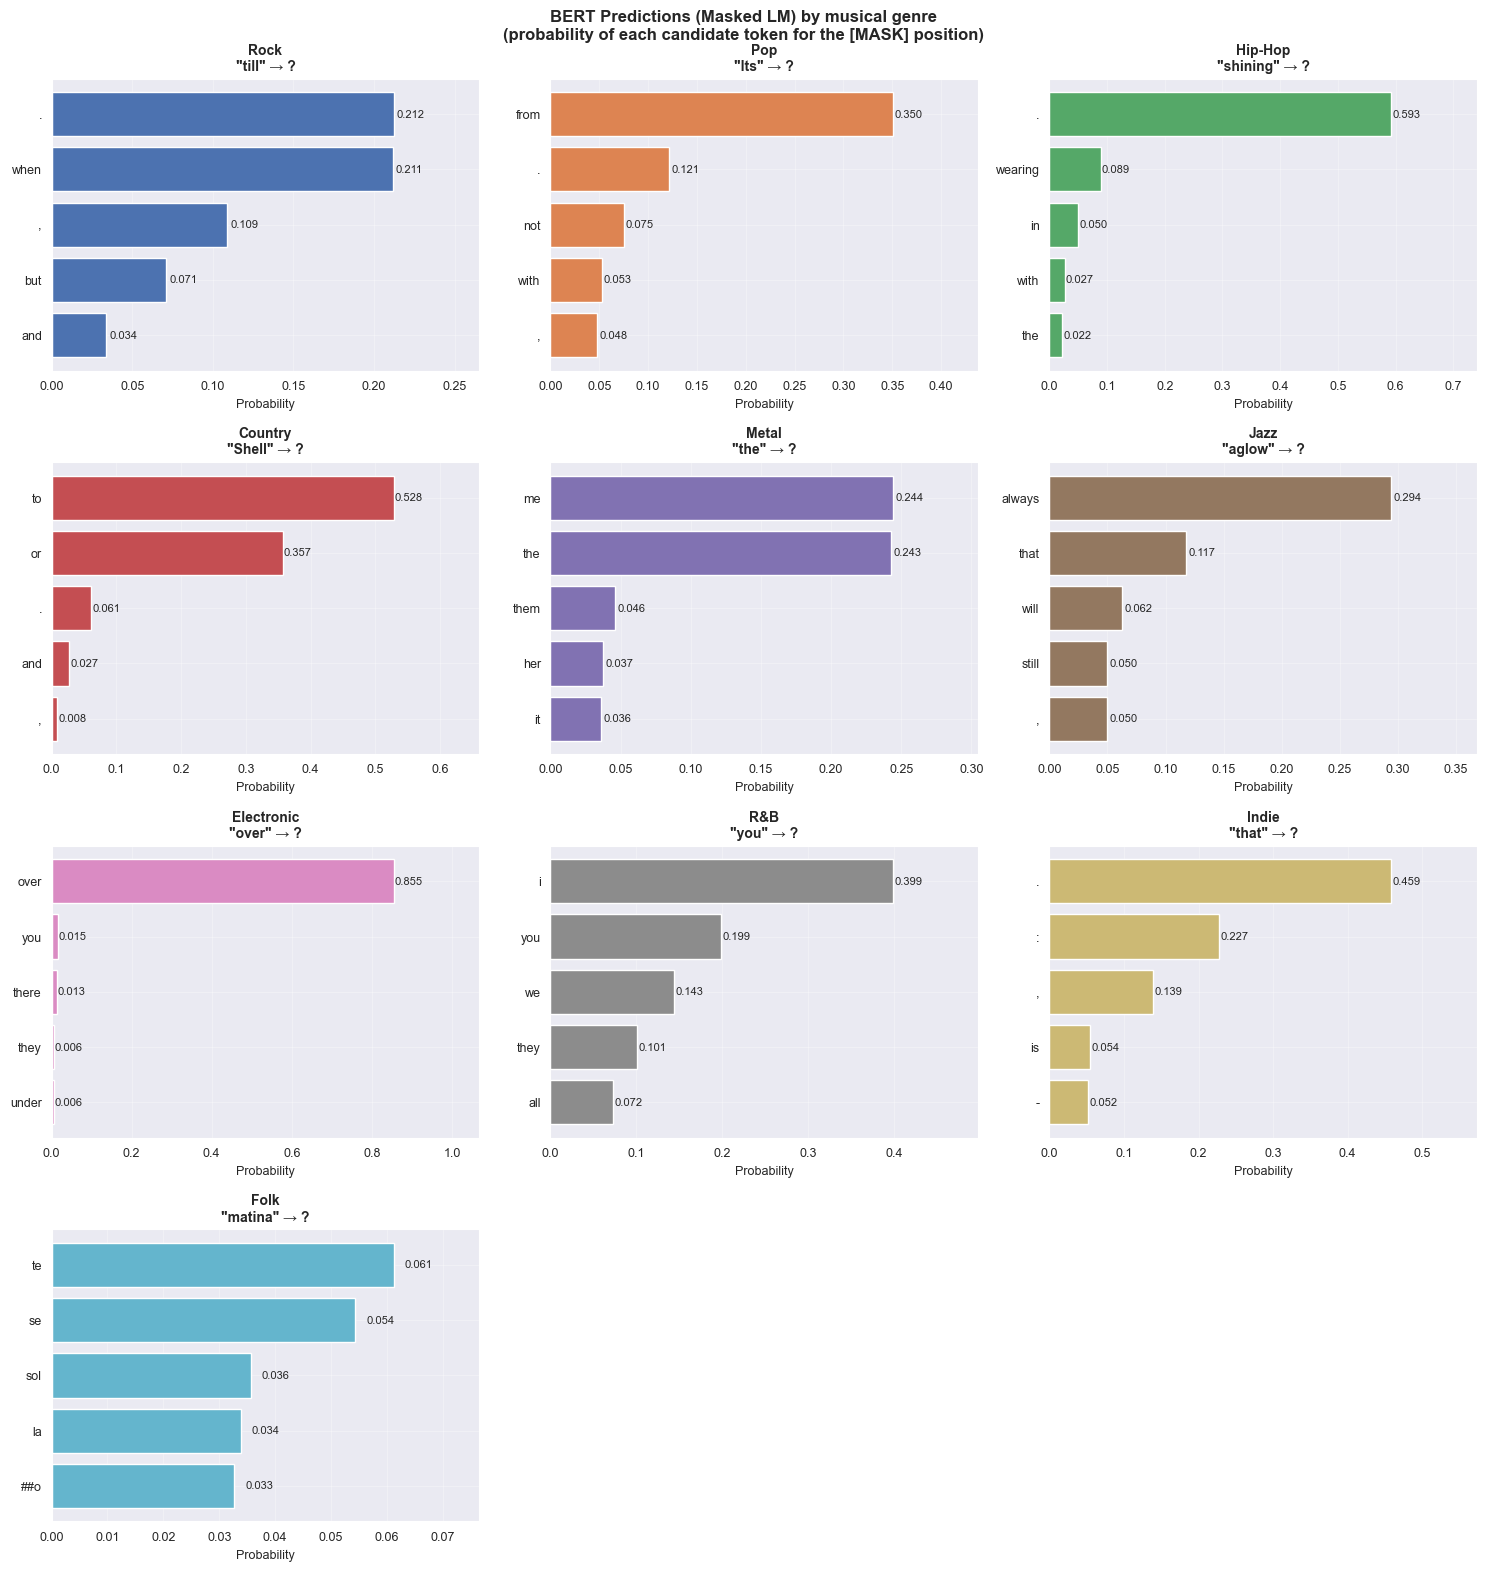

✓ Chart rendered for 10 genre(s)


In [55]:
if not mlm_por_genero:
    print("⚠ No MLM results to plot — all genres failed to build valid sentences.")
    print("  Check that df_proc contains lyrics with multi-word lines.")
else:
    generos_mlm = list(mlm_por_genero.keys())
    n_g   = len(generos_mlm)
    ncols = min(3, n_g)
    nrows = max(1, (n_g + ncols - 1) // ncols)
    pal   = (PALETTE * ((n_g // len(PALETTE)) + 1))[:n_g]

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4),
                             squeeze=False)
    axes = axes.flatten()

    for ax, genero, color in zip(axes, generos_mlm, pal):
        info  = mlm_por_genero[genero]
        preds = info['preds'][:5]
        tokens = [p for p, _ in preds]
        probs  = [s for _, s in preds]

        bars = ax.barh(tokens[::-1], probs[::-1], color=color, edgecolor='white')
        ax.set_title(f'{genero}\n"{info["real"]}" → ?', fontsize=10, fontweight='bold')
        ax.set_xlim(0, max(probs) * 1.25)
        ax.set_xlabel('Probability', fontsize=9)
        ax.tick_params(labelsize=9)
        for bar, prob in zip(bars, probs[::-1]):
            ax.text(bar.get_width() + 0.002,
                    bar.get_y() + bar.get_height() / 2,
                    f'{prob:.3f}', va='center', fontsize=8)

    for ax in axes[n_g:]:
        ax.axis('off')

    plt.suptitle(
        'BERT Predictions (Masked LM) by musical genre\n'
        '(probability of each candidate token for the [MASK] position)',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    print(f'✓ Chart rendered for {n_g} genre(s)')


---
## 8. t-SNE Projection of BERT Embeddings


Running t-SNE on 1000 songs × 768 dim...
✓ t-SNE complete


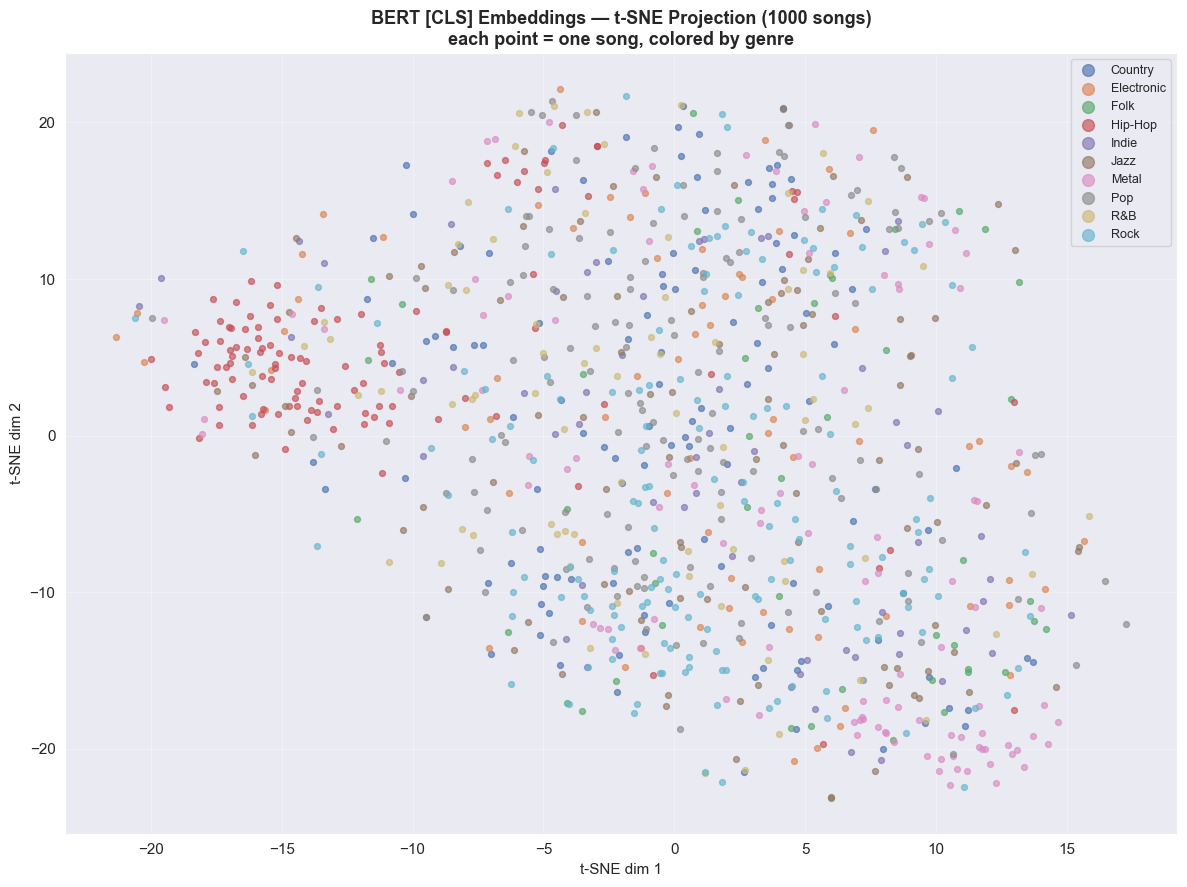

In [59]:
N_TSNE = min(1000, len(df_proc))   # limit for speed; increase if GPU available
df_tsne = df_proc.sample(N_TSNE, random_state=42).reset_index(drop=True)
mat_tsne = np.vstack(df_tsne['emb_beto'].tolist())

print(f'Running t-SNE on {N_TSNE} songs × 768 dim...')
coords_tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=40,
    max_iter=1000,
    init='pca',
    learning_rate='auto'
).fit_transform(mat_tsne)
print('✓ t-SNE complete')

generos_plot = df_tsne['Genre'].tolist()
generos_uniq = sorted(set(generos_plot))
color_map    = {g: PALETTE[i % len(PALETTE)] for i, g in enumerate(generos_uniq)}

fig, ax = plt.subplots(figsize=(12, 9))
for genero in generos_uniq:
    idx = [i for i, g in enumerate(generos_plot) if g == genero]
    ax.scatter(
        coords_tsne[idx, 0], coords_tsne[idx, 1],
        color=color_map[genero], label=genero,
        s=18, alpha=0.65, zorder=3
    )

ax.set_title(
    f'BERT [CLS] Embeddings — t-SNE Projection ({N_TSNE} songs)\n'
    'each point = one song, colored by genre',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(loc='best', fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()


In [57]:
# Genre centroid analysis — which genres are closest in BERT embedding space?
print('=== Genre similarity via BERT [CLS] centroids ===\n')

genre_centroids = {}
for genero in generos_uniq:
    idx = [i for i, g in enumerate(generos_plot) if g == genero]
    genre_centroids[genero] = mat_tsne[idx].mean(axis=0)

# Pairwise cosine similarity between genre centroids
from itertools import combinations
print(f"{'Genre A':<15} {'Genre B':<15} {'Cosine Similarity':>18}")
print('-' * 50)
pairs = []
for g1, g2 in combinations(generos_uniq, 2):
    sim = float(cosine_similarity(
        genre_centroids[g1].reshape(1, -1),
        genre_centroids[g2].reshape(1, -1)
    )[0][0])
    pairs.append((g1, g2, sim))

pairs.sort(key=lambda x: -x[2])
for g1, g2, sim in pairs:
    print(f"  {g1:<15} {g2:<15} {sim:.4f}")



=== Genre similarity via BERT [CLS] centroids ===

Genre A         Genre B          Cosine Similarity
--------------------------------------------------
  Pop             R&B             0.9971
  Electronic      Pop             0.9966
  Indie           Rock            0.9966
  Indie           Jazz            0.9957
  Electronic      Jazz            0.9957
  Electronic      Indie           0.9955
  Electronic      R&B             0.9953
  Jazz            Rock            0.9952
  Country         Pop             0.9952
  Indie           Pop             0.9949
  Indie           R&B             0.9947
  Electronic      Rock            0.9947
  Jazz            Pop             0.9945
  Jazz            R&B             0.9945
  Country         R&B             0.9945
  Folk            Jazz            0.9943
  Country         Jazz            0.9936
  Country         Indie           0.9934
  Pop             Rock            0.9933
  Folk            Rock            0.9931
  R&B             Rock     

---
## 9. Save Embeddings to MongoDB


In [58]:
print('Saving BERT embeddings to MongoDB...')
print('Strategy: $set only on embeddings.beto_cls (does not touch other fields)\n')

operaciones = []
sin_vector  = 0

for _, row in df_proc.iterrows():
    emb = row.get('emb_beto')
    if emb is None:
        sin_vector += 1
        continue
    operaciones.append(
        UpdateOne(
            {'_id': row['_id']},
            {'$set': {'embeddings.beto_cls': emb.tolist()}},
            upsert=False
        )
    )

LOTE      = 200   # lotes más pequeños que W2V por el tamaño del vector (768 floats)
guardados = 0
errores   = 0

for i in range(0, len(operaciones), LOTE):
    lote = operaciones[i: i + LOTE]
    try:
        r          = coleccion.bulk_write(lote, ordered=False)
        guardados += r.modified_count
    except Exception as e:
        errores += len(lote)
        print(f'  ⚠ Error en lote {i // LOTE + 1}: {e}')
    done = min(i + LOTE, len(operaciones))
    print(f'\r  {done}/{len(operaciones)} enviadas — modificadas: {guardados}',
          end='', flush=True)

print(f'\n\n✓ embeddings.beto_cls actualizado: {guardados}/{len(df_proc)} canciones')
if sin_vector: print(f'  Without vector: {sin_vector}')
if errores:    print(f'  ⚠ Errors: {errores} failed operations')

# Verificación rápida
sample = coleccion.find_one(
    {'_id': df_proc.iloc[0]['_id']},
    {'embeddings.beto_cls': 1}
)
if sample and sample.get('embeddings', {}).get('beto_cls'):
    dim = len(sample['embeddings']['beto_cls'])
    print(f'  Verification OK — stored vector dimension: {dim}')
else:
    print('  ⚠ Verification failed — check MongoDB connection')

Saving BERT embeddings to MongoDB...
Strategy: $set only on embeddings.beto_cls (does not touch other fields)

  8400/9230 enviadas — modificadas: 8400  ⚠ Error en lote 43: batch op errors occurred, full error: {'writeErrors': [{'index': 189, 'code': 28, 'errmsg': "Cannot create field 'beto_cls' in element {embeddings: null}", 'op': {'q': {'_id': ObjectId('69d816d5b8b402c44f44a1ab')}, 'u': {'$set': {'embeddings.beto_cls': [-1.180608868598938, 0.32441994547843933, -0.7899376153945923, -0.015943119302392006, -1.1346684694290161, 1.2512890100479126, 0.03682436794042587, 1.4106413125991821, -0.4369306266307831, 0.4338984191417694, -0.32619911432266235, -0.7525855898857117, -0.26084476709365845, 0.2512768805027008, -0.2665802836418152, -0.22289609909057617, 0.7091661095619202, 0.45204082131385803, 0.02655906416475773, 0.5976760387420654, -0.1495065689086914, -0.3899787366390228, 0.16308963298797607, -0.08124206215143204, 0.6040094494819641, -0.37860429286956787, -0.6026839017868042, 0.05632